In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

df_txn=pd.read_csv(r"../../data/raw/train_transaction.csv")
df_id=pd.read_csv(r"../../data/raw/train_identity.csv")


In [3]:
df=df_txn.merge(df_id,on='TransactionID',how='left')
print(f"Shape after join: {df.shape}")
print(f"\n Fraud distribution:")
print(df['isFraud'].value_counts())
print(df['isFraud'].value_counts(normalize=True))
df.to_csv("../../data/processed/merged_ieee.csv", index=False)

Shape after join: (590540, 434)

 Fraud distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64
isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


In [3]:
df=pd.read_csv(r"../../data/processed/merged_ieee.csv")
df.head()
               

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [4]:
fraud=df[df['isFraud']==1]
legit=df[df['isFraud']==0]

#### Amount Based EDA


In [6]:
df.groupby("isFraud")['TransactionAmt'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


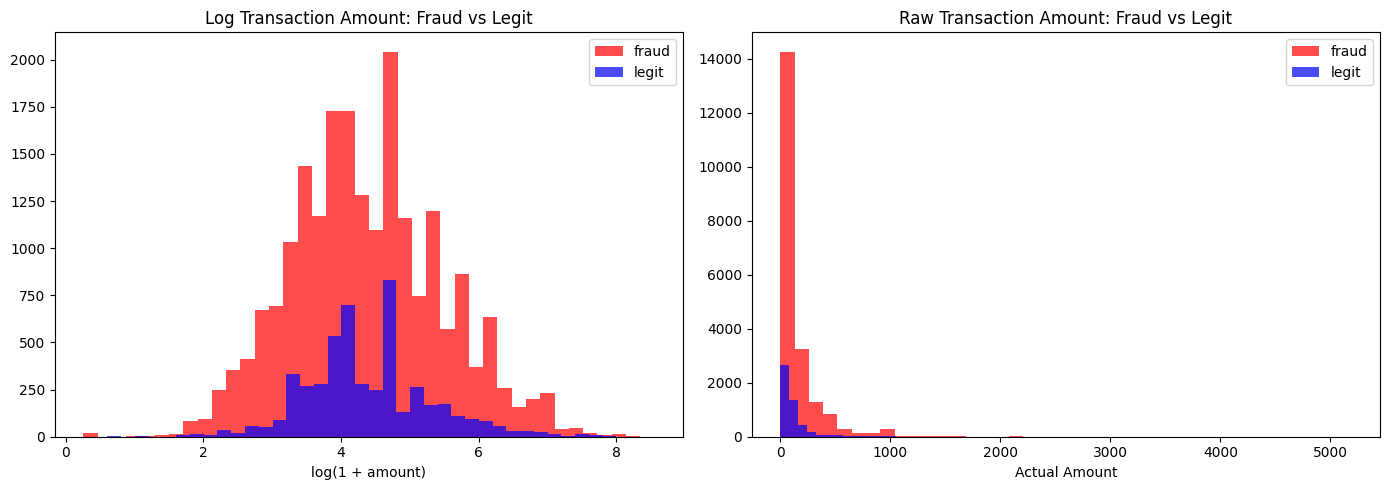

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(np.log1p(fraud['TransactionAmt']), bins=40, alpha=0.7,label='fraud', color='red')
axes[0].hist(np.log1p(legit['TransactionAmt'].sample(5000)), bins=40,alpha=0.7, label='legit', color='blue')
axes[0].legend()
axes[0].set_title('Log Transaction Amount: Fraud vs Legit')
axes[0].set_xlabel('log(1 + amount)')

axes[1].hist(fraud['TransactionAmt'], bins=40, alpha=0.7,label='fraud', color='red')
axes[1].hist(legit['TransactionAmt'].sample(5000), bins=40,alpha=0.7, label='legit', color='blue')
axes[1].legend()
axes[1].set_title('Raw Transaction Amount: Fraud vs Legit')
axes[1].set_xlabel('Actual Amount')
plt.tight_layout()
plt.show()

#### Product Based EDA

In [ ]:
df['ProductCD'].value_counts()

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

               mean   count
ProductCD                  
C          0.116873   68519
H          0.047662   33024
R          0.037826   37699
S          0.058996   11628
W          0.020399  439670


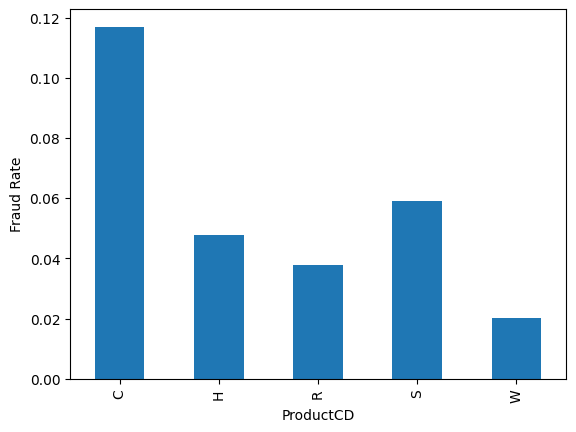

In [36]:
print(df.groupby('ProductCD')['isFraud'].agg(['mean','count']))
fraud_rate=df.groupby('ProductCD')['isFraud'].mean()
fraud_rate.plot(kind='bar')
plt.ylabel('Fraud Rate')
plt.show()

#### Time based EDA

In [49]:
df['hour']=df['TransactionDT']%86400//3600 
fraud_rate_by_hour=df.groupby('hour')['isFraud'].mean()
#86400 secs is 1 day
#3600 secs in 1 hr, so we are trying to classify by hour

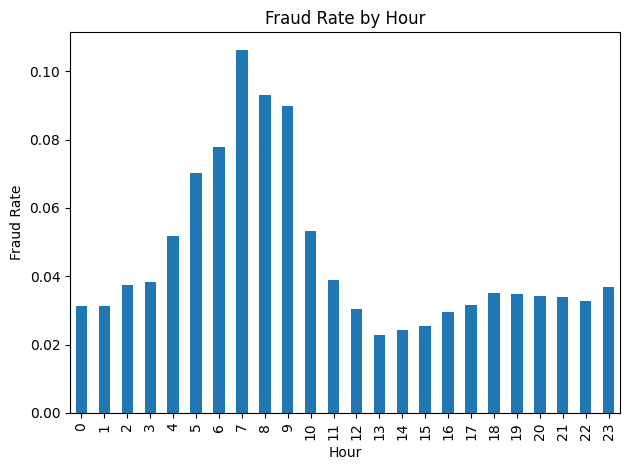

In [50]:
fraud_rate_by_hour.plot(kind='bar')
plt.xlabel('Hour')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Hour')
plt.tight_layout();
plt.show()

#### Email details

In [55]:
df.columns.to_list()

['TransactionID',
 'isFraud',
 'TransactionDT',
 'TransactionAmt',
 'ProductCD',
 'card1',
 'card2',
 'card3',
 'card4',
 'card5',
 'card6',
 'addr1',
 'addr2',
 'dist1',
 'dist2',
 'P_emaildomain',
 'R_emaildomain',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'D8',
 'D9',
 'D10',
 'D11',
 'D12',
 'D13',
 'D14',
 'D15',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V

In [57]:
df['missing_email']=(df['P_emaildomain'].isnull().astype(int))
df.groupby('missing_email')['isFraud'].mean()

missing_email
0    0.036028
1    0.029538
Name: isFraud, dtype: float64

In [59]:
df['email_mismatch']=(df['P_emaildomain']!=df['R_emaildomain']).astype(int)
df.groupby('email_mismatch')['isFraud'].mean()

email_mismatch
0    0.096504
1    0.022070
Name: isFraud, dtype: float64

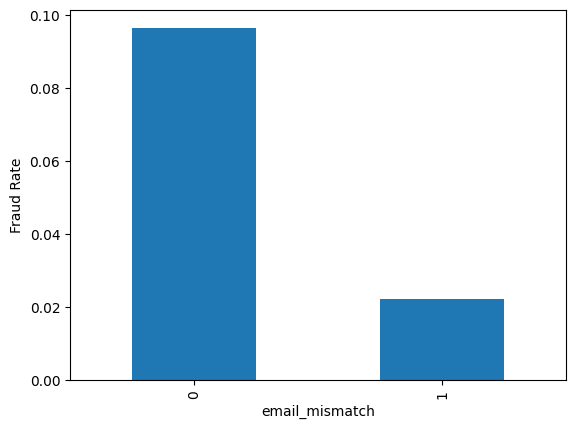

In [60]:
email_rates=df.groupby('email_mismatch')['isFraud'].mean()
email_rates.plot(kind='bar')
plt.ylabel('Fraud Rate')
plt.show()

#### Device details


In [61]:
print(df.groupby('DeviceType')['isFraud'].mean())

DeviceType
desktop    0.065215
mobile     0.101662
Name: isFraud, dtype: float64
